# Modelos por dimensión — TFG ML Lattice Cryptanalysis

Hipótesis: entrenar un modelo por cada dimensión `d` mejora el R² del RHF respecto al modelo global,
porque la relación features→targets cambia cualitativamente con `d` y la varianza intradimensional del RHF es baja.

Dataset: `lattice_dataset_v2.csv` (4 tipos de retículo, d ∈ {10,20,30,50,80,100,120,150,200})

In [6]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
from xgboost import XGBRegressor, XGBRFRegressor
from split_utils import reconstruct_base_id, load_test_base_ids

In [7]:
df = pd.read_csv('lattice_dataset_v2.csv')
print(df.shape)
print(df['d'].value_counts().sort_index())
print(df['lattice_type'].value_counts())

(224000, 30)
d
10     32000
20     32000
30     32000
50     32000
80     32000
100    16000
120    16000
150    16000
200    16000
Name: count, dtype: int64
lattice_type
uniform     56000
gaussian    56000
sparse      56000
qary        56000
Name: count, dtype: int64


## Features y targets

In [8]:
TARGETS = ['target_log_orth_defect', 'target_log_norm_b1', 'target_rhf']

FEATURE_COLS = [
    'log_det', 'norm_mean', 'norm_std', 'norm_max', 'norm_min', 'norm_ratio',
    'gso_mean', 'gso_std', 'gso_max', 'gso_min', 'gso_ratio', 'gso_slope', 'gso_res_std',
    'log_orth_defect', 'gram_off_diag_mean', 'gram_off_diag_max',
    'log_cond_num', 'mu_mean', 'mu_max', 'mu_frac_gt_05', 'std_B',
    'profile_mass', 'profile_entropy', 'profile_adjacency',
    'delta'
]

# base_id canónico añadido ANTES de get_dummies → se arrastra a df_enc
df['base_id'] = reconstruct_base_id(df)

# One-hot encoding de lattice_type
df_enc = pd.get_dummies(df, columns=['lattice_type'], drop_first=False)
lt_cols = [c for c in df_enc.columns if c.startswith('lattice_type_')]
FEATURE_COLS_GLOBAL  = FEATURE_COLS + ['d'] + lt_cols
FEATURE_COLS_PER_DIM = FEATURE_COLS + lt_cols  # sin 'd'

# Validación: exactamente 4 filas por base y features constantes dentro de cada base
_counts = df_enc.groupby('base_id').size()
assert (_counts == 4).all(), f"Algunas bases no tienen exactamente 4 filas:\n{_counts[_counts != 4]}"
_feat_check = [c for c in FEATURE_COLS if c != 'delta']
_max_var = df_enc.groupby('base_id')[_feat_check].var().max().max()
assert _max_var < 1e-10, f"Features no son constantes dentro de algunas bases (var máx = {_max_var:.2e})"
print(f"Aserción OK: {df_enc['base_id'].nunique()} bases únicas, todas con 4 filas y features constantes.")

Aserción OK: 56000 bases únicas, todas con 4 filas y features constantes.


## 1. Modelo global (baseline)

Incluye `d` y `lattice_type` como features.

In [4]:
def train_evaluate(X_train, X_test, y_train, y_test, label=''):
    scaler = StandardScaler()
    #entrena y transforma solo en train
    X_tr = scaler.fit_transform(X_train)
    #en test solo transforma evitando data leakage
    X_te = scaler.transform(X_test)

    rf = XGBRFRegressor(
        n_estimators=200, max_depth=15,
        device='cuda', tree_method='hist',
        subsample=0.8, colsample_bynode=0.8,
        random_state=42
    )
    gb = XGBRegressor(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        device='cuda', tree_method='hist',
        subsample=0.8, colsample_bytree=0.8,
        random_state=42
    )

    results = {}
    for name, model in [('RF', rf), ('GB', gb)]:
        model.fit(X_tr, y_train)
        y_pred = model.predict(X_te)
        results[name] = {
            'r2': r2_score(y_test, y_pred),
            'mae': mean_absolute_error(y_test, y_pred)
        }
        print(f"  {label} | {name}: R²={results[name]['r2']:.4f}  MAE={results[name]['mae']:.4f}")
    return results, {'RF': rf, 'GB': gb}, scaler

In [9]:
os.makedirs('models/global', exist_ok=True)

test_ids    = load_test_base_ids()
base_id_all = df_enc['base_id']
is_test     = base_id_all.isin(test_ids).to_numpy()
train_pos   = np.where(~is_test)[0]
test_pos    = np.where(is_test)[0]

assert not (set(base_id_all.iloc[train_pos]) & set(base_id_all.iloc[test_pos])), \
    "FUGA: base_ids comunes entre train y test (modelo global)"

global_results   = {}
global_gb_models = {}
global_scalers   = {}

for target in TARGETS:
    print(f"\n=== {target} ===")
    X = df_enc[FEATURE_COLS_GLOBAL].values
    y = df_enc[target].values
    X_train, X_test = X[train_pos], X[test_pos]
    y_train, y_test = y[train_pos], y[test_pos]
    results, models, scaler = train_evaluate(X_train, X_test, y_train, y_test, label='GLOBAL')
    global_results[target]   = results
    global_gb_models[target] = models['GB']
    global_scalers[target]   = scaler
    joblib.dump(models['GB'], f'models/global/gb_{target}.pkl')
    joblib.dump(scaler,       f'models/global/scaler_{target}.pkl')

print("\nModelos globales guardados en models/global/")


=== target_log_orth_defect ===


/home/a472259/miniconda3/envs/tfg_lattice/lib/python3.12/site-packages/xgboost/core.py:751: UserWarning: [22:46:17] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


  GLOBAL | RF: R²=0.9996  MAE=1.0761
  GLOBAL | GB: R²=0.9997  MAE=1.1083

=== target_log_norm_b1 ===
  GLOBAL | RF: R²=0.9783  MAE=0.0660
  GLOBAL | GB: R²=0.9775  MAE=0.0701

=== target_rhf ===
  GLOBAL | RF: R²=0.7531  MAE=0.0033
  GLOBAL | GB: R²=0.7499  MAE=0.0034

Modelos globales guardados en models/global/


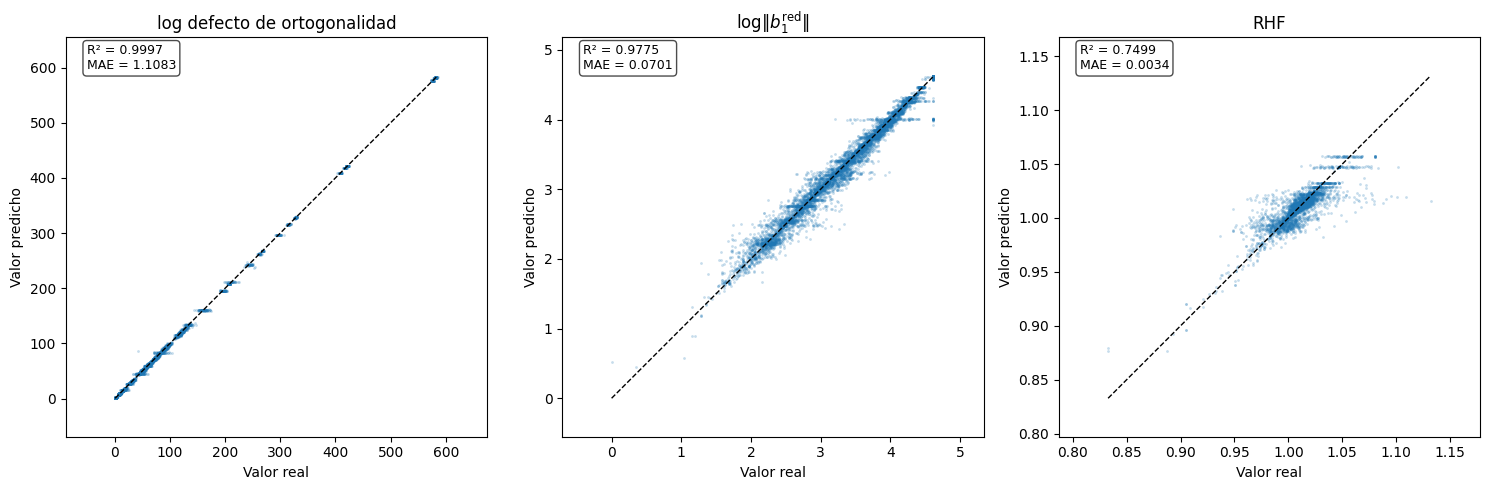

In [10]:
# Figura: predicted vs. actual — Modelo Global (GB) sobre test
import joblib, os

# Cargar modelos/scalers de disco si el kernel está limpio
if 'global_gb_models' not in dir() or not global_gb_models:
    global_gb_models = {t: joblib.load(f'models/global/gb_{t}.pkl') for t in TARGETS}
    global_scalers   = {t: joblib.load(f'models/global/scaler_{t}.pkl') for t in TARGETS}

TARGET_LABELS = {
    'target_log_orth_defect': 'log defecto de ortogonalidad',
    'target_log_norm_b1':     r'log$\|b_1^{\mathrm{red}}\|$',
    'target_rhf':             'RHF',
}

MAX_SCATTER = 8000
rng = np.random.default_rng(42)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, target in zip(axes, TARGETS):
    y_true = df_enc[target].values[test_pos]
    X_test = df_enc[FEATURE_COLS_GLOBAL].values[test_pos]
    y_pred = global_gb_models[target].predict(global_scalers[target].transform(X_test))

    r2  = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)

    if len(y_true) > MAX_SCATTER:
        idx = rng.choice(len(y_true), MAX_SCATTER, replace=False)
        yt, yp = y_true[idx], y_pred[idx]
    else:
        yt, yp = y_true, y_pred

    ax.scatter(yt, yp, s=4, alpha=0.25, linewidths=0)

    lo = min(yt.min(), yp.min())
    hi = max(yt.max(), yp.max())
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1, label='y = x')

    ax.set_xlabel('Valor real')
    ax.set_ylabel('Valor predicho')
    ax.set_title(TARGET_LABELS[target])
    ax.set_aspect('equal', adjustable='datalim')
    ax.annotate(f'R² = {r2:.4f}\nMAE = {mae:.4f}', xy=(0.05, 0.92),
                xycoords='axes fraction', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

plt.tight_layout()
os.makedirs('graphs', exist_ok=True)
plt.savefig('graphs/pred_vs_actual_global.png', dpi=150)
plt.show()


## 2. Modelos por dimensión

Para cada `d`, se filtra el dataset y se entrena sin `d` como feature.
Si el R² del RHF mejora respecto al global, confirma que la relación features→RHF es distinta por dimensión.

In [11]:
os.makedirs('models/per_dim', exist_ok=True)

dimensions = sorted(df['d'].unique())
per_dim_results = {d: {} for d in dimensions}
test_indices_per_dim = {}

per_dim_gb_models = {}
per_dim_scalers = {}

# Checkpoint con nombre canónico (invalida splits previos no estratificados)
results_ckpt  = 'models/per_dim/results_checkpoint_canonical.pkl'
test_idx_ckpt = 'models/per_dim/test_indices_checkpoint_canonical.pkl'
if os.path.exists(results_ckpt) and os.path.exists(test_idx_ckpt):
    per_dim_results      = joblib.load(results_ckpt)
    test_indices_per_dim = joblib.load(test_idx_ckpt)
    print(f"Resultados y test_indices previos cargados desde {results_ckpt}")

for d in dimensions:
    df_d = df_enc[df_enc['d'] == d]

    # Split canónico: mismo conjunto de test que en todos los notebooks
    base_id_d = df_d['base_id']
    is_test_d = base_id_d.isin(test_ids).to_numpy()
    train_pos_d, test_pos_d = np.where(~is_test_d)[0], np.where(is_test_d)[0]

    assert not (set(base_id_d.iloc[train_pos_d]) & set(base_id_d.iloc[test_pos_d])), \
        f"FUGA en d={d}: base_ids comunes entre train y test"

    # Guardar índices de test (DataFrame index) para reutilizar en celda de evaluación estratificada
    test_indices_per_dim[d] = df_d.index[test_pos_d]

    X = df_d[FEATURE_COLS_PER_DIM].values

    print(f"\n--- d={d} ({len(df_d)} filas, {df_d['base_id'].nunique()} bases) ---")
    for target in TARGETS:
        gb_path     = f'models/per_dim/gb_{target}_d{d}.pkl'
        scaler_path = f'models/per_dim/scaler_{target}_d{d}.pkl'

        already_done = (
            os.path.exists(gb_path) and
            os.path.exists(scaler_path) and
            d in per_dim_results and
            target in per_dim_results.get(d, {})
        )

        if already_done:
            print(f"  Saltando d={d}, {target} — checkpoint encontrado, cargando desde disco")
            gb     = joblib.load(gb_path)
            scaler = joblib.load(scaler_path)
            results = per_dim_results[d][target]
        else:
            y = df_d[target].values
            X_train, X_test = X[train_pos_d], X[test_pos_d]
            y_train, y_test = y[train_pos_d], y[test_pos_d]
            results, models, scaler = train_evaluate(X_train, X_test, y_train, y_test, label=f'd={d}')
            gb = models['GB']

            per_dim_results[d][target] = results

            joblib.dump(gb,     gb_path)
            joblib.dump(scaler, scaler_path)
            joblib.dump(per_dim_results,      results_ckpt)
            joblib.dump(test_indices_per_dim, test_idx_ckpt)

        if target == 'target_rhf':
            per_dim_gb_models[d] = gb
            per_dim_scalers[d]   = scaler

joblib.dump(test_indices_per_dim, test_idx_ckpt)

Resultados y test_indices previos cargados desde models/per_dim/results_checkpoint_canonical.pkl

--- d=10 (32000 filas, 8000 bases) ---
  Saltando d=10, target_log_orth_defect — checkpoint encontrado, cargando desde disco
  Saltando d=10, target_log_norm_b1 — checkpoint encontrado, cargando desde disco
  Saltando d=10, target_rhf — checkpoint encontrado, cargando desde disco

--- d=20 (32000 filas, 8000 bases) ---
  Saltando d=20, target_log_orth_defect — checkpoint encontrado, cargando desde disco
  Saltando d=20, target_log_norm_b1 — checkpoint encontrado, cargando desde disco
  Saltando d=20, target_rhf — checkpoint encontrado, cargando desde disco

--- d=30 (32000 filas, 8000 bases) ---
  Saltando d=30, target_log_orth_defect — checkpoint encontrado, cargando desde disco
  Saltando d=30, target_log_norm_b1 — checkpoint encontrado, cargando desde disco
  Saltando d=30, target_rhf — checkpoint encontrado, cargando desde disco

--- d=50 (32000 filas, 8000 bases) ---
  Saltando d=50, 

['models/per_dim/test_indices_checkpoint_canonical.pkl']

In [7]:
# Los modelos ya se guardaron en disco celda a celda durante el entrenamiento.
# Esta celda solo lista lo que hay en models/per_dim/ como verificación.
print("Archivos en models/per_dim/:")
for f in sorted(os.listdir('models/per_dim')):
    print(f"  {f}")

Archivos en models/per_dim/:
  gb_target_log_norm_b1_d10.pkl
  gb_target_log_norm_b1_d100.pkl
  gb_target_log_norm_b1_d120.pkl
  gb_target_log_norm_b1_d150.pkl
  gb_target_log_norm_b1_d20.pkl
  gb_target_log_norm_b1_d200.pkl
  gb_target_log_norm_b1_d30.pkl
  gb_target_log_norm_b1_d50.pkl
  gb_target_log_norm_b1_d80.pkl
  gb_target_log_orth_defect_d10.pkl
  gb_target_log_orth_defect_d100.pkl
  gb_target_log_orth_defect_d120.pkl
  gb_target_log_orth_defect_d150.pkl
  gb_target_log_orth_defect_d20.pkl
  gb_target_log_orth_defect_d200.pkl
  gb_target_log_orth_defect_d30.pkl
  gb_target_log_orth_defect_d50.pkl
  gb_target_log_orth_defect_d80.pkl
  gb_target_rhf_d10.pkl
  gb_target_rhf_d100.pkl
  gb_target_rhf_d120.pkl
  gb_target_rhf_d150.pkl
  gb_target_rhf_d20.pkl
  gb_target_rhf_d200.pkl
  gb_target_rhf_d30.pkl
  gb_target_rhf_d50.pkl
  gb_target_rhf_d80.pkl
  results_checkpoint.pkl
  results_checkpoint_canonical.pkl
  scaler_target_log_norm_b1_d10.pkl
  scaler_target_log_norm_b1_d100.pk

In [8]:
# Guardar resultados globales y per-dim a JSON para que dim_mlps.ipynb los cargue
import json as _json

def _to_serializable(obj):
    """Convierte numpy floats a Python floats para serialización JSON."""
    if isinstance(obj, dict):
        return {str(k): _to_serializable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_to_serializable(x) for x in obj]
    if hasattr(obj, 'item'):  # numpy scalar
        return obj.item()
    return obj

results_export = {
    'global': _to_serializable(global_results),
    'per_dim': _to_serializable(per_dim_results),
}

out_path = 'models/per_dim/xgb_results.json'
with open(out_path, 'w') as _f:
    _json.dump(results_export, _f, indent=2)
print(f"Resultados guardados en {out_path}")

Resultados guardados en models/per_dim/xgb_results.json


## 3. Comparativa global vs. por dimensión

In [12]:
## Comparativa per-dim vs global sobre las MISMAS bases de test por dimensión
#
# MAE es la métrica primaria (independiente de la varianza del target).
# R² se informa para ambos modelos evaluados sobre el mismo y_true,
# lo que hace los denominadores comparables entre sí para una misma d.

print(f"{'d':>5} | {'MAE per-dim':>12} {'MAE global':>12} | {'R2 per-dim':>11} {'R2 global':>11}")
print("-" * 65)

for d in dimensions:
    m = is_test & (df_enc['d'] == d).to_numpy()
    if m.sum() == 0:
        continue
    y_true   = df_enc.loc[m, 'target_rhf'].to_numpy()
    X_global = df_enc.loc[m, FEATURE_COLS_GLOBAL].to_numpy()
    X_perdim = df_enc.loc[m, FEATURE_COLS_PER_DIM].to_numpy()

    y_glob = global_gb_models['target_rhf'].predict(
                 global_scalers['target_rhf'].transform(X_global))
    y_pd   = per_dim_gb_models[d].predict(
                 per_dim_scalers[d].transform(X_perdim))

    mae_pd = mean_absolute_error(y_true, y_pd)
    mae_gl = mean_absolute_error(y_true, y_glob)
    if np.var(y_true) < 1e-20:
        r2_pd = r2_gl = float('nan')
    else:
        r2_pd = r2_score(y_true, y_pd)
        r2_gl = r2_score(y_true, y_glob)
    print(f"{d:>5} | {mae_pd:>12.6f} {mae_gl:>12.6f} | {r2_pd:>11.4f} {r2_gl:>11.4f}")

    d |  MAE per-dim   MAE global |  R2 per-dim   R2 global
-----------------------------------------------------------------
   10 |     0.012130     0.012342 |      0.5142      0.5038
   20 |     0.004965     0.005144 |      0.7175      0.7147
   30 |     0.003025     0.003258 |      0.8713      0.8686
   50 |     0.001320     0.001498 |      0.9686      0.9655
   80 |     0.000597     0.000703 |      0.9876      0.9881
  100 |     0.000376     0.000542 |      0.9947      0.9920
  120 |     0.000241     0.000356 |      0.9968      0.9955
  150 |     0.000195     0.000263 |      0.9923      0.9958
  200 |     0.000123     0.000231 |      0.9977      0.9947


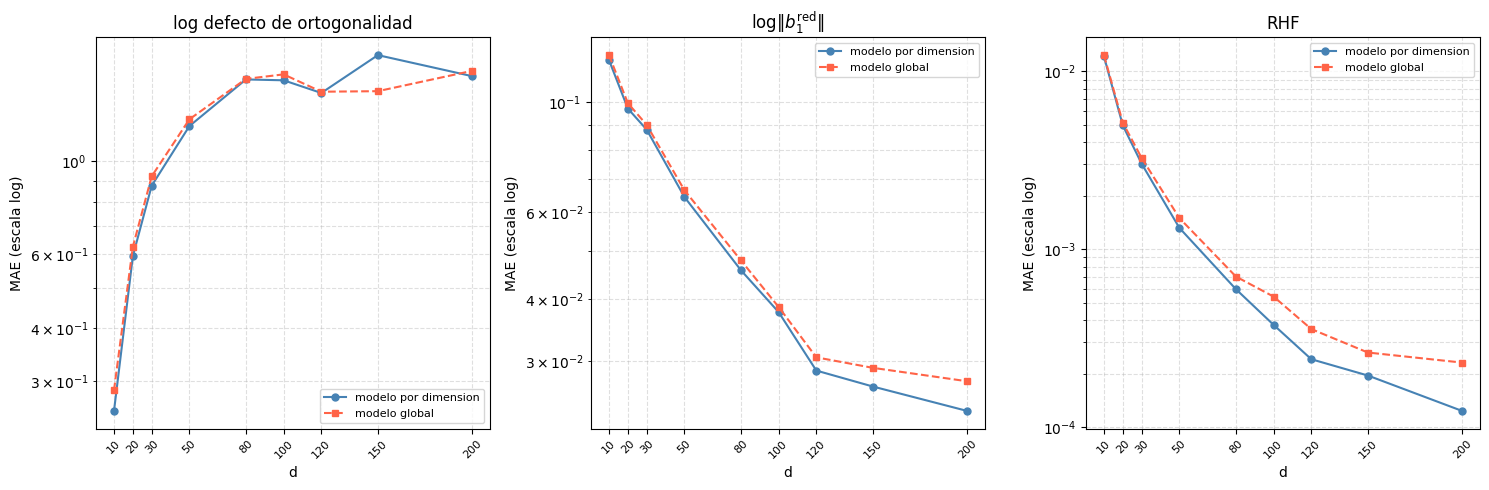

In [13]:
## Comparativa per-dim vs global — MAE para los tres targets

import os, joblib

# Comprobacion previa: todos los modelos por dimension deben existir en disco
_missing = []
for _t in TARGETS:
    for _d in dimensions:
        for _suffix in [f"gb_{_t}_d{_d}.pkl", f"scaler_{_t}_d{_d}.pkl"]:
            if not os.path.exists(f"models/per_dim/{_suffix}"):
                _missing.append(_suffix)
if _missing:
    raise RuntimeError(
        "Faltan modelos por dimension en disco — re-ejecuta la celda de "
        "entrenamiento por dimension:\n" + "\n".join(_missing)
    )

TARGET_LABELS_MAE = {
    "target_log_orth_defect": "log defecto de ortogonalidad",
    "target_log_norm_b1":     r"log$\|b_1^{\mathrm{red}}\|$",
    "target_rhf":             "RHF",
}

mae_perdim = {t: [] for t in TARGETS}
mae_global = {t: [] for t in TARGETS}
dims_valid = {t: [] for t in TARGETS}

for target in TARGETS:
    for d in dimensions:
        m = is_test & (df_enc["d"] == d).to_numpy()
        if m.sum() == 0:
            continue
        y_true   = df_enc.loc[m, target].to_numpy()
        X_global = df_enc.loc[m, FEATURE_COLS_GLOBAL].to_numpy()
        X_perdim = df_enc.loc[m, FEATURE_COLS_PER_DIM].to_numpy()

        y_glob = global_gb_models[target].predict(
            global_scalers[target].transform(X_global)
        )

        # Para target_rhf usar memoria si disponible; resto cargar de disco
        if target == "target_rhf" and d in per_dim_gb_models:
            modelo_pd = per_dim_gb_models[d]
            scaler_pd = per_dim_scalers[d]
        else:
            modelo_pd = joblib.load(f"models/per_dim/gb_{target}_d{d}.pkl")
            scaler_pd = joblib.load(f"models/per_dim/scaler_{target}_d{d}.pkl")

        y_pd = modelo_pd.predict(scaler_pd.transform(X_perdim))

        mae_perdim[target].append(mean_absolute_error(y_true, y_pd))
        mae_global[target].append(mean_absolute_error(y_true, y_glob))
        dims_valid[target].append(d)

COLOR_PERDIM = "steelblue"
COLOR_GLOBAL = "tomato"

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, target in zip(axes, TARGETS):
    ds = dims_valid[target]
    ax.semilogy(ds, mae_perdim[target], "o-",  color=COLOR_PERDIM,
                label="modelo por dimension", linewidth=1.5, markersize=5)
    ax.semilogy(ds, mae_global[target],  "s--", color=COLOR_GLOBAL,
                label="modelo global",      linewidth=1.5, markersize=5)
    ax.set_xticks(ds)
    ax.set_xticklabels(ds, rotation=45, fontsize=8)
    ax.set_xlabel("d")
    ax.set_ylabel("MAE (escala log)")
    ax.set_title(TARGET_LABELS_MAE[target])
    ax.legend(fontsize=8)
    ax.grid(True, which="both", linestyle="--", alpha=0.4)

plt.tight_layout()
os.makedirs("graphs", exist_ok=True)
plt.savefig("graphs/mae_perdim_vs_global.png", dpi=150)
plt.show()


## 4. Análisis por tipo de retículo

Comparamos R² por tipo de retículo usando el modelo global.

In [10]:
lattice_types = df['lattice_type'].unique()

for lt in sorted(lattice_types):
    df_lt = df_enc[df['lattice_type'] == lt]
    print(f"\n--- lattice_type={lt} ({len(df_lt)} filas) ---")

    base_id_lt = df_lt['base_id']
    is_test_lt = base_id_lt.isin(test_ids).to_numpy()
    train_pos_lt, test_pos_lt = np.where(~is_test_lt)[0], np.where(is_test_lt)[0]
    assert not (set(base_id_lt.iloc[train_pos_lt]) & set(base_id_lt.iloc[test_pos_lt])), \
        f"FUGA en lattice_type={lt}"

    for target in TARGETS:
        X = df_lt[FEATURE_COLS_GLOBAL].values
        y = df_lt[target].values
        X_train, X_test = X[train_pos_lt], X[test_pos_lt]
        y_train, y_test = y[train_pos_lt], y[test_pos_lt]
        train_evaluate(X_train, X_test, y_train, y_test, label=lt)


--- lattice_type=gaussian (56000 filas) ---
  gaussian | RF: R²=0.9988  MAE=0.8269
  gaussian | GB: R²=0.9988  MAE=0.8158
  gaussian | RF: R²=0.9765  MAE=0.0624
  gaussian | GB: R²=0.9770  MAE=0.0629
  gaussian | RF: R²=0.4989  MAE=0.0030
  gaussian | GB: R²=0.4898  MAE=0.0031

--- lattice_type=qary (56000 filas) ---
  qary | RF: R²=0.9997  MAE=1.8859
  qary | GB: R²=0.9997  MAE=1.8561
  qary | RF: R²=0.9709  MAE=0.0890
  qary | GB: R²=0.9714  MAE=0.0900
  qary | RF: R²=0.6870  MAE=0.0044
  qary | GB: R²=0.6760  MAE=0.0046

--- lattice_type=sparse (56000 filas) ---
  sparse | RF: R²=0.9989  MAE=0.7928
  sparse | GB: R²=0.9989  MAE=0.8022
  sparse | RF: R²=0.9764  MAE=0.0639
  sparse | GB: R²=0.9769  MAE=0.0658
  sparse | RF: R²=0.7760  MAE=0.0029
  sparse | GB: R²=0.7725  MAE=0.0030

--- lattice_type=uniform (56000 filas) ---
  uniform | RF: R²=0.9989  MAE=0.7707
  uniform | GB: R²=0.9988  MAE=0.8180
  uniform | RF: R²=0.9869  MAE=0.0457
  uniform | GB: R²=0.9839  MAE=0.0523
  uniform

     d |          gaussian          |            qary            |           sparse           |          uniform          
       |         R²         MAE   |         R²         MAE   |         R²         MAE   |         R²         MAE  
--------------------------------------------------------------------------------------------------------------------------------
    10 |     0.3477    0.011661  |     0.2211    0.014959  |     0.7313    0.010664  |     0.4733    0.011236  | 
    20 |     0.6252    0.004056  |     0.6379    0.007520  |     0.7327    0.004043  |     0.5986    0.004244  | 
    30 |     0.6760    0.002223  |     0.8120    0.005589  |     0.7217    0.002450  |     0.6531    0.001837  | 
    50 |     0.6743    0.001104  |     0.9235    0.002118  |     0.7238    0.001196  |     0.6375    0.000861  | 
    80 |     0.6405    0.000597  |     0.8728    0.000711  |     0.6564    0.000671  |     0.6660    0.000408  | 
   100 |     0.6878    0.000429  |     0.8413    0.000277  |   

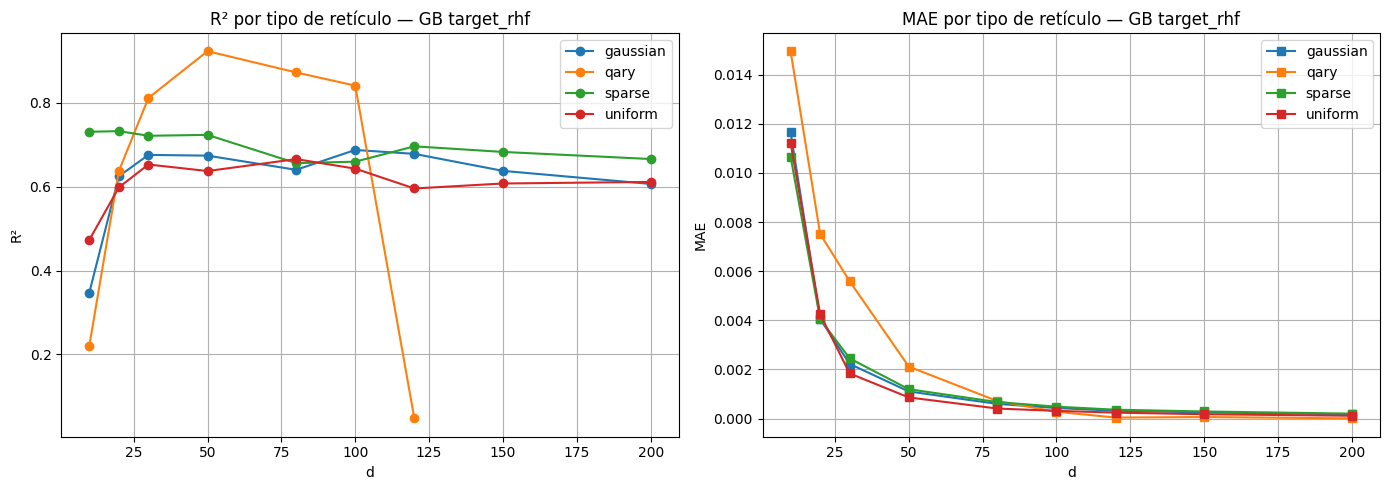

In [11]:
lattice_types_sorted = sorted(df['lattice_type'].unique())
target = 'target_rhf'

strat_results = {d: {} for d in dimensions}

for d in dimensions:
    df_d = df_enc[df_enc['d'] == d].copy()
    idx_test = test_indices_per_dim[d]   # índices DataFrame del split agrupado (celda 9)

    X_test = df_d.loc[idx_test, FEATURE_COLS_PER_DIM].values
    y_test = df_d.loc[idx_test, target].values

    scaler = per_dim_scalers[d]
    model  = per_dim_gb_models[d]
    X_test_scaled = scaler.transform(X_test)
    y_pred_all = model.predict(X_test_scaled)

    lt_labels = df['lattice_type'].loc[idx_test].values
    for lt in lattice_types_sorted:
        mask = lt_labels == lt
        if mask.sum() == 0:
            continue
        y_true_lt = y_test[mask]
        y_pred_lt = y_pred_all[mask]
        mae = mean_absolute_error(y_true_lt, y_pred_lt)
        # R² es indefinido cuando la varianza del target es ~0 (e.g. qary RHF a alta d)
        if np.var(y_true_lt) < 1e-20:
            r2 = float('nan')
        else:
            r2 = r2_score(y_true_lt, y_pred_lt)
        strat_results[d][lt] = {'r2': r2, 'mae': mae}

# ── Tabla resumen ──────────────────────────────────────────────────────────────
print(f"{'d':>6} | " + " | ".join(f"{lt:^26}" for lt in lattice_types_sorted))
print(f"{'':>6} | " + " | ".join(f"{'R²':>10}  {'MAE':>10}  " for _ in lattice_types_sorted))
print("-" * (8 + 30 * len(lattice_types_sorted)))
for d in dimensions:
    row = f"{d:>6} | "
    for lt in lattice_types_sorted:
        r = strat_results[d].get(lt, {})
        r2_val = r.get('r2', float('nan'))
        mae_val = r.get('mae', float('nan'))
        r2_str = f"{r2_val:>10.4f}" if not np.isnan(r2_val) else f"{'NaN (var≈0)':>10}"
        row += f"{r2_str}  {mae_val:>10.6f}  | "
    print(row)

# ── Gráfico: R² por tipo de retículo y dimensión ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for lt in lattice_types_sorted:
    r2_vals  = [strat_results[d].get(lt, {}).get('r2',  float('nan')) for d in dimensions]
    mae_vals = [strat_results[d].get(lt, {}).get('mae', float('nan')) for d in dimensions]
    axes[0].plot(dimensions, r2_vals,  'o-', label=lt)
    axes[1].plot(dimensions, mae_vals, 's-', label=lt)

for ax, ylabel, title in zip(
    axes,
    ['R²', 'MAE'],
    ['R² por tipo de retículo — GB target_rhf', 'MAE por tipo de retículo — GB target_rhf']
):
    ax.set_xlabel('d')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.savefig('graphs/strat_by_lattice_type.png', dpi=150)
plt.show()

## 5. Evaluación estratificada por tipo de retículo (modelos por dimensión)

Para cada dimensión `d`, se evalúa el mejor modelo (`GB`, target `target_rhf`) sobre el conjunto de test,
desglosando las métricas R² y MAE por tipo de retículo.
Esto permite detectar si algún tipo de retículo es sistemáticamente más difícil de predecir.